# scikit-learn模型构建

## 使用sklearn转换器处理数据

### 加载`datasets`模块中的数据集

sklearn库中的`datasets`模块集成了部分数据分析的经典数据集，可以使用这些数据集熟悉sklearn的数据处理流程和建模流程

In [2]:
import numpy as np
import pandas as pd
from sklearn import datasets

加载后的数据集可以视为一个字典，几乎所有的sklearn数据集均可以使用`data`, `target`, `feature_names`, `DESCR`分别获取数据集的数据，标签，特征名称和描述信息。

In [3]:
# 加载 boston 数据集
from sklearn.datasets import load_boston
boston = load_boston()

In [4]:
# 数据集被加载时，它们是Bunch类型
# Bunch是python常用的数据结构。基本可以看成一个字典
type(boston)

sklearn.utils.Bunch

In [5]:
for k in boston.keys():
    print(k)

data
target
feature_names
DESCR
filename


In [6]:
boston.data

array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
        4.9800e+00],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
        9.1400e+00],
       [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
        4.0300e+00],
       ...,
       [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        5.6400e+00],
       [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
        6.4800e+00],
       [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        7.8800e+00]])

In [7]:
boston.target

array([24. , 21.6, 34.7, 33.4, 36.2, 28.7, 22.9, 27.1, 16.5, 18.9, 15. ,
       18.9, 21.7, 20.4, 18.2, 19.9, 23.1, 17.5, 20.2, 18.2, 13.6, 19.6,
       15.2, 14.5, 15.6, 13.9, 16.6, 14.8, 18.4, 21. , 12.7, 14.5, 13.2,
       13.1, 13.5, 18.9, 20. , 21. , 24.7, 30.8, 34.9, 26.6, 25.3, 24.7,
       21.2, 19.3, 20. , 16.6, 14.4, 19.4, 19.7, 20.5, 25. , 23.4, 18.9,
       35.4, 24.7, 31.6, 23.3, 19.6, 18.7, 16. , 22.2, 25. , 33. , 23.5,
       19.4, 22. , 17.4, 20.9, 24.2, 21.7, 22.8, 23.4, 24.1, 21.4, 20. ,
       20.8, 21.2, 20.3, 28. , 23.9, 24.8, 22.9, 23.9, 26.6, 22.5, 22.2,
       23.6, 28.7, 22.6, 22. , 22.9, 25. , 20.6, 28.4, 21.4, 38.7, 43.8,
       33.2, 27.5, 26.5, 18.6, 19.3, 20.1, 19.5, 19.5, 20.4, 19.8, 19.4,
       21.7, 22.8, 18.8, 18.7, 18.5, 18.3, 21.2, 19.2, 20.4, 19.3, 22. ,
       20.3, 20.5, 17.3, 18.8, 21.4, 15.7, 16.2, 18. , 14.3, 19.2, 19.6,
       23. , 18.4, 15.6, 18.1, 17.4, 17.1, 13.3, 17.8, 14. , 14.4, 13.4,
       15.6, 11.8, 13.8, 15.6, 14.6, 17.8, 15.4, 21

In [8]:
print(boston.DESCR)

.. _boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pu

In [9]:
boston.filename

'/Library/Frameworks/Python.framework/Versions/3.8/lib/python3.8/site-packages/sklearn/datasets/data/boston_house_prices.csv'

In [10]:
# data属性对应的数据作为自变量，用target属性对应的数据作为因变量
X, y = boston.data, boston.target
print(X)
print(y)

[[6.3200e-03 1.8000e+01 2.3100e+00 ... 1.5300e+01 3.9690e+02 4.9800e+00]
 [2.7310e-02 0.0000e+00 7.0700e+00 ... 1.7800e+01 3.9690e+02 9.1400e+00]
 [2.7290e-02 0.0000e+00 7.0700e+00 ... 1.7800e+01 3.9283e+02 4.0300e+00]
 ...
 [6.0760e-02 0.0000e+00 1.1930e+01 ... 2.1000e+01 3.9690e+02 5.6400e+00]
 [1.0959e-01 0.0000e+00 1.1930e+01 ... 2.1000e+01 3.9345e+02 6.4800e+00]
 [4.7410e-02 0.0000e+00 1.1930e+01 ... 2.1000e+01 3.9690e+02 7.8800e+00]]
[24.  21.6 34.7 33.4 36.2 28.7 22.9 27.1 16.5 18.9 15.  18.9 21.7 20.4
 18.2 19.9 23.1 17.5 20.2 18.2 13.6 19.6 15.2 14.5 15.6 13.9 16.6 14.8
 18.4 21.  12.7 14.5 13.2 13.1 13.5 18.9 20.  21.  24.7 30.8 34.9 26.6
 25.3 24.7 21.2 19.3 20.  16.6 14.4 19.4 19.7 20.5 25.  23.4 18.9 35.4
 24.7 31.6 23.3 19.6 18.7 16.  22.2 25.  33.  23.5 19.4 22.  17.4 20.9
 24.2 21.7 22.8 23.4 24.1 21.4 20.  20.8 21.2 20.3 28.  23.9 24.8 22.9
 23.9 26.6 22.5 22.2 23.6 28.7 22.6 22.  22.9 25.  20.6 28.4 21.4 38.7
 43.8 33.2 27.5 26.5 18.6 19.3 20.1 19.5 19.5 20.4 19.8 19.

### 将数据集划分为训练集喝测试集

**做预测分析时（一般是指有监督学习），可以讲数据分为两部分。一部分是训练数据，用于构建模型；一部分是测试数据，用于检验模型。**


**（1）数据集的划分**

在数据分析过程中，为了保证模型在实际系统中能够起到预期作用，一股需要将样本分成独立的三部分：

**训练集(train set）**：用于估计模型。

**验证集(validation set)**：用于确定网络结构或者控制模型复杂程度的參数。

**测试集 (test set）**：用于检验最优的模型的性能。

典型的划分方式是训练集占总样本的50%，而验证集和测试集各占25%。如果不划分验证集，则训练集和测试集一般为`8：2`或`7：3`开。

**（2）K折交叉验正法**

当数据总量较少的时候，使用上面的方法将数据划分为三部分就不合适了。

常用的方法是留少部分做测试集，然后对其余N个样本采用K折交叉验证法，基本步骤如下：

将样本打乱，均匀分成K份。

轮流选择其中K-1份做训练，剩余的一份做验证。

计算预测误差平方和，把K次的预测误差平方和的均值作为选择最优模型结构的依据。

**（3）`train test split`函数**

sklearn的`model_selection`模块提供了`train_ test_split`函数，能够对数据集进行拆分。

注：`train test_split`函数根据传入的数据，分别将传入的数据划分为训练集和测试集。如果传入的是1组数据，那么生成的就是这一组数据随机划分后训综集和测试集，总共2组。如果传入的是2组数据，则生成的训练集和测试集分别2组，总共4组。`train_test_ split`是最常用的数据划分方法，在`model_selection`模块中还提供了其它数据集划分的函数，如`ShuffleSplit`.

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(boston.data,
                                                    boston.target,
                                                    test_size=0.2,
                                                    random_state=123)

In [13]:
X_train.shape

(404, 13)

In [14]:
X_test.shape

(102, 13)

In [15]:
y_train.shape

(404,)

In [16]:
y_test.shape

(102,)

### 使用sklearn转化器进行数据预处理与降维

sklearn把相关的功能封装为转换器（transfomer）。使用sklearn转换器能够实现对传入的Numpy数组进行标准化处理，归一化处理，二值化处理，PCA降维等操作。

- 在数据分析的过程中，各类特征处理的操作都需要对训练集和测试集分开操作，需要将训练集的操作规则，权重系数等应用到测试集中。
- 如果使用pandas，则应用至测试集的过程相对繁琐，使用sklearn转换器可以解决这一困扰。

**sklearn部分预处理函数与其作用（sklearn.preprocessing模块）**

In [17]:
from sklearn.preprocessing import MinMaxScaler

In [19]:
scaler = MinMaxScaler().fit(X_train)   # 生成规则

In [20]:
# 将规则应用于训练集，进行转换
boston_train_scaler = scaler.transform(X_train)

In [21]:
boston_test_scaler = scaler.transform(X_test)

In [22]:
np.min(X_train)

0.0

In [23]:
np.min(boston_train_scaler)

0.0

In [24]:
np.max(X_train)

711.0

In [25]:
np.max(boston_train_scaler)

1.0

In [26]:
from sklearn.preprocessing import StandardScaler

In [30]:
X_train_scaler = StandardScaler().fit_transform(X_train)

In [31]:
np.mean(X_train_scaler)

2.0090555266636496e-15

In [32]:
np.std(X_train_scaler)

0.9999999999999998

**PCA降维算法函数常用参数及其作用（了解）**

In [33]:
from sklearn.decomposition import PCA

In [35]:
pca_model = PCA(n_components=10).fit(boston_train_scaler)   # 生成规则

In [36]:
# 讲规则应用于训练集
boston_train_pca = pca_model.transform(boston_train_scaler)

In [37]:
boston_train_scaler.shape

(404, 13)

In [38]:
boston_train_pca.shape

(404, 10)

# 构建并评价聚类模型

## 使用sklearn估计器构建聚类模型

In [40]:
# 使用sklearn估计器构建Kmeans聚类模型
# 使用iris数据集
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [41]:
# 1. load数据集
# 直接使用sklearn自带的数据集
# 在实际情况下，需要自己读取数据
iris = load_iris()

In [42]:
# 特征、标签、特征名，是数据的三大基本要素，一定要清楚
iris_data = iris['data']
iris_target = iris['target']
iris_names = iris['feature_names']

In [43]:
iris_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [44]:
# 2. 预处理、标准化
scale = MinMaxScaler().fit(iris_data)   # 训练规则
iris_data_scale = scale.transform(iris_data)   # 应用规则

In [46]:
# 3. 建模
kmeans = KMeans(n_clusters=3, random_state=123).fit(iris_data)

In [47]:
kmeans

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=300,
       n_clusters=3, n_init=10, n_jobs=None, precompute_distances='auto',
       random_state=123, tol=0.0001, verbose=0)

## 补充K-means参数解释

`sklearn.cluster.KMeans(nclusters=8, init='k-means++', ninit=10, maxiter=300, tol=0.0001, precompute_distances='auto', verbose=0, random_state=None, copy_x=True, n_jobs=None, algorithm='auto')`

**输入**
1. `n_clusters`: int, optional, default: 8，表示要聚关生成的族的数量，也就是聚类中心的数量。要求输入为整效型，默认值为8
2. `init`: {k-means++，random' or an ndarray}，表示对进行聚类的数据初始化的方法，默认的方法是'K-means++'。初始化的方法有三种：k-means++, random或者是一个数组。k-means+ +能智能的选择初始聚关中心进行k均值聚类，加快收敛速度：random则是从数据中随机的选择k个观测值作为初始值；聚关中心 ：也可以传递给init一个数组作为初始化的聚关中心，则这个数组的结构应该是(n_ clusters, n_features），后附代码则是利用数组进行初始化；
3. `n_init`: int, default: 10，表示K-means算法选择聚类中心的次数，默认值为10。算法最终返回的是聚类中心最好的一次结果，也就是时间最短的一次结果；
4. `max_iter`: int, default：300，表示每次运行K-means算法的最大迭代次数，默认值为300；
5. `tol`: roat, default：1e-4，表示容忍度，相当于是迭代终止的精度要求或者可以允许的误差，当满足这个精度则聚类收敛，认为寻找到最优解，此时可以停止迭代，默认值为0.0001;
6. `precompute_distances`: {auto, True, False}，表示预先计算距离，在空间和时间上作出权衡。相当于是否需要判断-用空问来换取时间”，即如果选择true处理时间会更快，但是会占用更多的内存，默认值为auto'；auto'指如果八_samples *n_clusters ＞ 121亿时 ，就不预先计算距高。这样就相当于使用双精度的每个作业大约需要100MB的内存；True'指总是预先计算距离；False'指不预先计算距离;
7. `verbose`: int, default 0，是否输出详细信息，默认值为0；
8. `random_state`: int, RandomState instance or None (default)，确定聚类中心初始化的随机数生成，使用一个整型数使得随机性具有确定性 ，默认值为None；
9. `copy_x`: boolean, optional， bool 在scikit-earn 很多接口中都会有这个参数的，就是是否对输入数据继续copy 操作，以便不修改用户的输入数据，默认值为True。 True时，是不修改原始数据，确保X是C-contiguous，聚类后不修改原始数据；False时，则修改原始数据，在西数返回之前柠修改后的放回X，但通过減去再加上效据均值，可能会引入较小的数值差异，在这种情况下也不能保证数据是C-contiguous，可能会使速度明显的下降;
10. `n_jobs`: int or None, optional (derault=None)，使用进程的数量，与电脑CPU有关。默认值为None;
11. `algorithm`: “auto”, “ul or "elkan”, default='auto”， K-means算法所用到的"Tl指经典的EM-style算法；“elkan”通过使用三角不等式，优点是处理更加高效，但不支持稀疏的数据；'auto'则在数据密集时，选择'elkan'，在数据稀疏时，选择'full';

**输出**

1. `cluster_centers_`: 返回聚类中心的坐标;
2. `labels_`: 每个点的标签;
3. `inertia_`: 样本到聚类中心的平方和，聚类准则的总和;
4. `n_iter_`: 迭代运行的次数.

In [48]:
# 获取聚类结果，每类的中心
kmeans.cluster_centers_

array([[5.006     , 3.428     , 1.462     , 0.246     ],
       [6.85      , 3.07368421, 5.74210526, 2.07105263],
       [5.9016129 , 2.7483871 , 4.39354839, 1.43387097]])

In [49]:
# 获取聚类结果，每条记录对应聚到哪个类中
kmeans.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2], dtype=int32)

In [50]:
# 获取聚类结果，样本到聚类中心的平方和
kmeans.inertia_

78.85144142614601

In [51]:
# 获取聚类结果，迭代运行的次数
kmeans.n_iter_

4

In [62]:
# 4. 运用构建的模型，根据传入的数据划分类别
result = kmeans.predict([[1.5, 1.5, 1.5, 1.5], [6.5, 3, 5.2, 2], [6.3, 2.5, 5, 1.9]])

In [63]:
result

array([0, 1, 2], dtype=int32)

## TSNE函数降维实现多维数据的可视化展现

聚类完成后需要通过可视化的方式查看聚类效果，通过sklearn的`manifold`模块中的TSNE函数可以实现多维数据的可视化展现。其原理是使用TSNE进行数据降维，降成两维。

In [64]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pylab as plt
%matplotlib inline

In [75]:
tsne = TSNE(n_components=2, init='random', random_state=177).fit(iris_data)

In [76]:
iris_data_t = pd.DataFrame(tsne.embedding_)   # 转换成DataFrame

In [77]:
iris_data_t['labels'] = kmeans.labels_   # 将聚类结果存储进df数据表

In [78]:
# 提取不同标签的数据
iris_data_t1 = iris_data_t[iris_data_t['labels']==0]
iris_data_t2 = iris_data_t[iris_data_t['labels']==1]
iris_data_t3 = iris_data_t[iris_data_t['labels']==2]

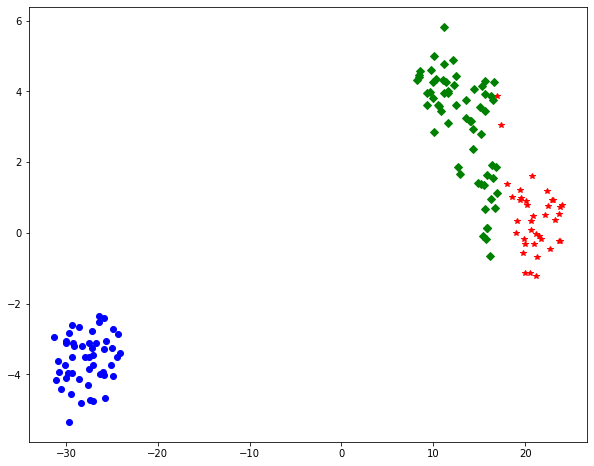

In [79]:
fig = plt.figure(figsize=(10, 8))
plt.plot(iris_data_t1[0], iris_data_t1[1], 'bo',
         iris_data_t2[0], iris_data_t2[1], 'r*',
         iris_data_t3[0], iris_data_t3[1], 'gD')
plt.show()

### 评价聚类模型

聚类评价的标准是组内的对象相互之间是相似的（相关的），而不同组中的对象是不同的（不相关的）。即组内的相似性越大，组问差别越大，聚类效果就越好。

sklearn的`metrics`模块提供的聚类模型评价指标。`from sklearn.metrics import xxx`

- 总共列出了6种评价的方法，其中前4种方法均需要真实值的配合才能够评价聚类算法的优劣，后2种则不需要真实值的配合。但是前4种方法评价的效果更具有说服力，并且在实际运行的过程中在有真实值做参考的情况下，聚类方法的评价可以等同于分类算法的评价。

- 除了轮廓系数以外的评价方法，在不考虑业务场暴的情况下都是得分越高，其效果越好 ，最高分 值均为1。而轮廓示数则需要判断不同类别数目的情况下其轮廓系数的走势，寻找最优的聚类数目。

- 在具备真实值作为参考的情况下，几种方法均可以很好地评估聚类模型。在没有真实值作为参考的时候，轮廓系数评价方法和Calinski-Harabasz指数评价方法可以结合使用。

**使用轮廓系数评价KMeans聚类模型**

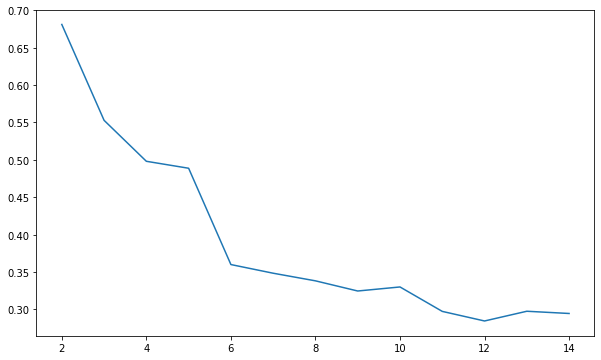

In [81]:
from sklearn.metrics import silhouette_score
import matplotlib.pylab as plt
silhouetteScore = []
for i in range(2, 15):
    kmeans = KMeans(n_clusters=i, random_state=123).fit(iris_data)
    score = silhouette_score(iris_data, kmeans.labels_)
    silhouetteScore.append(score)
plt.figure(figsize=(10, 6))
plt.plot(range(2, 15), silhouetteScore, lw=1.5, ls='-')
plt.show()

**使用Calinski_Harabasz方法评价聚类模型**

In [83]:
from sklearn.metrics import calinski_harabasz_score

In [84]:
for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, random_state=123).fit(iris_data)
    score = calinski_harabasz_score(iris_data, kmeans.labels_)
    print('iris数据聚{}类calinski_harabasz指数为:{}'.format(i, score))

iris数据聚2类calinski_harabasz指数为:513.9245459802768
iris数据聚3类calinski_harabasz指数为:561.62775662962
iris数据聚4类calinski_harabasz指数为:530.7658081872851
iris数据聚5类calinski_harabasz指数为:495.54148767768777
iris数据聚6类calinski_harabasz指数为:469.83663313290083


> calinski_harabas指数分数越高，聚类效果越好，故可以看出3类为最优聚类类别。